In [3]:
# Paketleri yükleme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data_path = "Online_Sales_Data.csv"
data = pd.read_csv(data_path)
data.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [27]:
data.shape

(240, 9)

In [15]:
data.columns

Index(['Transaction ID', 'Date', 'Product Category', 'Product Name',
       'Units Sold', 'Unit Price', 'Total Revenue', 'Region',
       'Payment Method'],
      dtype='object')

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


In [17]:
data.describe()

,Transaction ID,Units Sold,Unit Price,Total Revenue
count,240.00000,240.000000,240.000000,240.000000
mean,10120.50000,2.158333,236.395583,335.699375
std,69.42622,1.322454,429.446695,485.804469
min,10001.00000,1.000000,6.500000,6.500000
25%,10060.75000,1.000000,29.500000,62.965000
50%,10120.50000,2.000000,89.990000,179.970000
75%,10180.25000,3.000000,249.990000,399.225000
max,10240.00000,10.000000,3899.990000,3899.990000


In [18]:
data.isnull().sum()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

In [29]:
total_revenue = data["Total Revenue"].sum()
total_revenue

80567.84999999999

In [30]:
# En çok gelir getiren ürünler
top_products = data.groupby("Product Name")["Total Revenue"].sum().sort_values(ascending=False)
top_products

Product Name
Canon EOS R5 Camera                            3899.99
LG OLED TV                                     2599.98
MacBook Pro 16-inch                            2499.99
Apple MacBook Pro 16-inch                      2399.00
iPhone 14 Pro                                  1999.98
                                                ...   
Neutrogena Hydro Boost Water Gel                 16.99
Biore UV Aqua Rich Watery Essence Sunscreen      15.00
The Ordinary Hyaluronic Acid Serum                6.80
The Ordinary Caffeine Solution 5% + EGCG          6.70
The Ordinary Niacinamide Serum                    6.50
Name: Total Revenue, Length: 232, dtype: float64

In [32]:
# Ülkelerin gelir analizi
regional_revenue = data.groupby("Region")["Total Revenue"].sum().sort_values(ascending=False)
regional_revenue

Region
North America    36844.34
Asia             22455.45
Europe           21268.06
Name: Total Revenue, dtype: float64

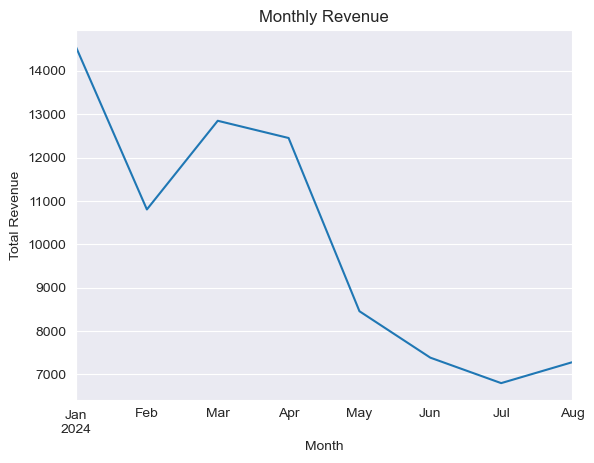

In [35]:
# Aylık Gelir Eğilimi
data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.to_period("M")

month_revenue = data.groupby("Month")["Total Revenue"].sum()
month_revenue.plot(kind="line",title="Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()
